In [215]:
import pandas as pd

In [216]:
df = pd.read_csv("ann_customer_churn_1000.csv")

In [217]:
df.head()

,customer_age,tenure_years,monthly_charges,support_calls,contract_type,internet_service,payment_method,online_security,tech_support,churn
0,56,7,23.07,2,One year,Fiber optic,Credit card,Yes,Yes,0
1,69,5,45.77,0,Two year,No,Bank transfer,Yes,No,0
2,46,9,66.26,4,Two year,DSL,Credit card,No,Yes,0
3,32,6,106.83,1,One year,Fiber optic,Mailed check,No,No,0
4,60,7,92.72,5,Month-to-month,DSL,Credit card,Yes,Yes,1


In [218]:
df.shape

(1000, 10)

In [219]:
df.columns

Index(['customer_age', 'tenure_years', 'monthly_charges', 'support_calls',
       'contract_type', 'internet_service', 'payment_method',
       'online_security', 'tech_support', 'churn'],
      dtype='str')

In [220]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_age      1000 non-null   int64  
 1   tenure_years      1000 non-null   int64  
 2   monthly_charges   1000 non-null   float64
 3   support_calls     1000 non-null   int64  
 4   contract_type     1000 non-null   str    
 5   internet_service  1000 non-null   str    
 6   payment_method    1000 non-null   str    
 7   online_security   1000 non-null   str    
 8   tech_support      1000 non-null   str    
 9   churn             1000 non-null   int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 78.3 KB


In [221]:
df.isnull().sum()

customer_age        0
tenure_years        0
monthly_charges     0
support_calls       0
contract_type       0
internet_service    0
payment_method      0
online_security     0
tech_support        0
churn               0
dtype: int64

In [222]:
df["churn"].value_counts()

churn
0    633
1    367
Name: count, dtype: int64

In [223]:
X = df.drop("churn",axis= 1)

In [224]:
X.head()

,customer_age,tenure_years,monthly_charges,support_calls,contract_type,internet_service,payment_method,online_security,tech_support
0,56,7,23.07,2,One year,Fiber optic,Credit card,Yes,Yes
1,69,5,45.77,0,Two year,No,Bank transfer,Yes,No
2,46,9,66.26,4,Two year,DSL,Credit card,No,Yes
3,32,6,106.83,1,One year,Fiber optic,Mailed check,No,No
4,60,7,92.72,5,Month-to-month,DSL,Credit card,Yes,Yes


In [225]:
Y = df["churn"]

In [226]:
Y.head()

0    0
1    0
2    0
3    0
4    1
Name: churn, dtype: int64

In [227]:
X.shape

(1000, 9)

In [228]:
Y.shape


(1000,)

In [229]:
X.select_dtypes(include = "object").columns

C:\Users\rohit\AppData\Local\Temp\ipykernel_18352\2019526332.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include = "object").columns


Index(['contract_type', 'internet_service', 'payment_method',
       'online_security', 'tech_support'],
      dtype='str')

In [230]:
X = pd.get_dummies(X , drop_first = True)

In [231]:
X.head()

,customer_age,tenure_years,monthly_charges,support_calls,contract_type_One year,contract_type_Two year,internet_service_Fiber optic,internet_service_No,payment_method_Credit card,payment_method_Electronic check,payment_method_Mailed check,online_security_Yes,tech_support_Yes
0,56,7,23.07,2,True,False,True,False,True,False,False,True,True
1,69,5,45.77,0,False,True,False,True,False,False,False,True,False
2,46,9,66.26,4,False,True,False,False,True,False,False,False,True
3,32,6,106.83,1,True,False,True,False,False,False,True,False,False
4,60,7,92.72,5,False,False,False,False,True,False,False,True,True


In [232]:
X= X.astype(int)

In [233]:
X.head()

,customer_age,tenure_years,monthly_charges,support_calls,contract_type_One year,contract_type_Two year,internet_service_Fiber optic,internet_service_No,payment_method_Credit card,payment_method_Electronic check,payment_method_Mailed check,online_security_Yes,tech_support_Yes
0,56,7,23,2,1,0,1,0,1,0,0,1,1
1,69,5,45,0,0,1,0,1,0,0,0,1,0
2,46,9,66,4,0,1,0,0,1,0,0,0,1
3,32,6,106,1,1,0,1,0,0,0,1,0,0
4,60,7,92,5,0,0,0,0,1,0,0,1,1


In [234]:
from sklearn.model_selection import train_test_split 


In [235]:
x_train,x_test,y_train,y_test = train_test_split(X ,Y ,test_size = 0.2 , random_state= 42,stratify=Y)

In [236]:
from sklearn.preprocessing import StandardScaler

In [237]:
Scaler = StandardScaler()

In [238]:
x_train = Scaler.fit_transform(x_train)
x_test = Scaler.transform(x_test)

In [239]:
x_train.shape

(800, 13)

In [240]:
import sys
print(sys.version)

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]


In [241]:
import tensorflow as tf

In [242]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [243]:
model = Sequential()

In [244]:
model.add(Dense(16 ,activation ="relu", input_shape=(13,)))
model.add(Dense(8 ,activation = "relu"))
model.add(Dense(1, activation="sigmoid"))

C:\Users\rohit\ann_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [245]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 16)                  │             224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [246]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
    
)

In [247]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [248]:
history = model.fit(x_train, y_train ,epochs=26, validation_split=0.2,callbacks=[early_stop])

Epoch 1/26
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5562 - loss: 0.7010 - val_accuracy: 0.5625 - val_loss: 0.6807
Epoch 2/26
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5969 - loss: 0.6693 - val_accuracy: 0.6125 - val_loss: 0.6517
Epoch 3/26
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6328 - loss: 0.6453 - val_accuracy: 0.6500 - val_loss: 0.6293
Epoch 4/26
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6500 - loss: 0.6249 - val_accuracy: 0.6625 - val_loss: 0.6103
Epoch 5/26
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6672 - loss: 0.6076 - val_accuracy: 0.6750 - val_loss: 0.5916
Epoch 6/26
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6844 - loss: 0.5903 - val_accuracy: 0.6750 - val_loss: 0.5758
Epoch 7/26
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6906 - loss: 0.5742 - val_accuracy: 0.7000 - val_loss: 0.5605
Epoch 8/26
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7031 - loss: 0.5594 - val_accuracy: 0.7000 - val_loss:

In [249]:
len(history.history["loss"])

26

In [250]:
model.evaluate(x_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8300 - loss: 0.4178 


[0.41782936453819275, 0.8299999833106995]

In [251]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

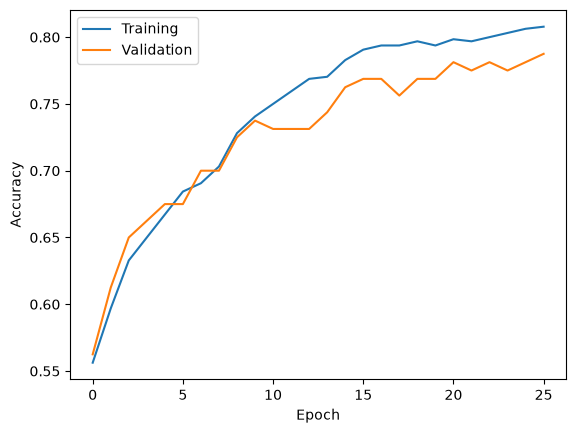

In [252]:

import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])
plt.show()

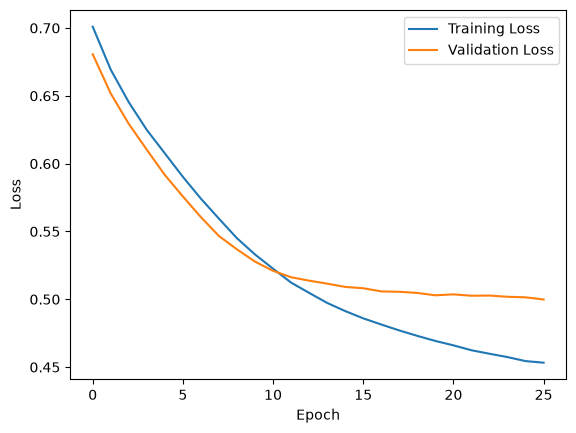

In [253]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])
plt.show()

In [254]:
y_pred = model.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [255]:
y_pred[:10]

array([[0.10103841],
       [0.38853577],
       [0.49381632],
       [0.31028968],
       [0.1694962 ],
       [0.00825042],
       [0.73823965],
       [0.04176427],
       [0.22016296],
       [0.17229547]], dtype=float32)

In [256]:
y_pred_class = (y_pred >= 0.5).astype(int)

In [257]:
from sklearn.metrics import accuracy_score

In [258]:
accuracy_score(y_test, y_pred_class)

0.83

In [259]:
from sklearn.metrics import confusion_matrix

In [260]:
cm = confusion_matrix(y_test, y_pred_class)

In [261]:
cm

array([[113,  14],
       [ 20,  53]])

In [262]:
from sklearn.metrics import precision_score

In [263]:
precision_score(y_test, y_pred_class)

0.7910447761194029

In [264]:
from sklearn.metrics import recall_score

In [265]:
recall_score(y_test, y_pred_class)

0.726027397260274

In [266]:
from sklearn.metrics import f1_score

In [267]:
f1_score(y_test, y_pred_class)

0.7571428571428571

In [268]:
from sklearn.metrics import classification_report

In [269]:
print(classification_report(y_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       127
           1       0.79      0.73      0.76        73

    accuracy                           0.83       200
   macro avg       0.82      0.81      0.81       200
weighted avg       0.83      0.83      0.83       200



In [270]:
model.save("customer_churn_ann.keras")

In [271]:
scaler = StandardScaler()

In [272]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [273]:
import os
os.listdir()

['.ipynb_checkpoints',
 'ANN.ipynb',
 'ann_customer_churn_1000.csv',
 'customer_churn_ann.keras',
 'scaler.pkl',
 'Untitled.ipynb']